# Learning the Logical Channel from Syndrome Information

This notebook demonstrates the full pipeline for learning logical error probabilities from circuit-level syndrome data.

**Pipeline:**
1. **Build code** — construct a CSS code (rotated surface code)
2. **Syndrome extraction** — build a noisy stim circuit, sample detector/observable outcomes, extract the DEM
3. **Benchmark** — compare sampled LEP (direct Monte Carlo decoding) vs predicted LEP (from syndrome-learned priors)

In [1]:
import numpy as np
from bposd.css import css_code
from sim_qec.codes_family.hpc_lp import rotated_surface_code_checks
from sim_qec.pipeline import (
    SyndromeExtractionConfig,
    run_syndrome_extraction,
    benchmark_lep,
)
from sim_qec.detector_error_models.dem_sim import CircuitErrorParams

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Step 1: Build the CSS Code

We use the rotated surface code of distance $d$, constructed via `rotated_surface_code_checks` and wrapped in `bposd.css.css_code`.

In [2]:
d = 3
Hx, Hz = rotated_surface_code_checks(d)
code = css_code(Hx, Hz)

print(f"Code: [[{code.N}, {code.K}, d={d}]]")
print(f"Hx shape: {code.hx.shape}, Hz shape: {code.hz.shape}")
print(f"CSS condition Hx @ Hz^T = 0: {np.all((code.hx @ code.hz.T) % 2 == 0)}")

Code: [[9, 1, d=3]]
Hx shape: (4, 9), Hz shape: (4, 9)
CSS condition Hx @ Hz^T = 0: True


## Step 2: Syndrome Extraction

Configure the circuit-level noise model and run the syndrome extraction experiment.
The `num_samples_true_lep` parameter controls how many fresh shots are used
in `benchmark_lep` to compute the ground-truth LEP.

In [14]:
config = SyndromeExtractionConfig(
    num_cycles=1,
    physical_error_rate=5e-4,
    shots=5_000_000,
    num_samples_true_lep=100_000_000,
    fault_type="DEPOLARIZE1",
    circuit_error_params=CircuitErrorParams(
        p_i=1.0,
        p_state_p=0.8,
        p_m=0.9,
        p_CX=1.0,
        p_idling_gate=0.0,
    ),
)

result = run_syndrome_extraction(code, config)

Syndrome extraction circuit scheduling for X stabilizers: [{np.int64(23): 34, np.int64(21): 13, np.int64(20): 35, np.int64(19): 28, np.int64(18): 14, np.int64(17): 40, np.int64(16): 38, np.int64(15): 36, np.int64(14): 32, np.int64(13): 31, np.int64(12): 29, np.int64(11): 26, np.int64(10): 24, np.int64(1): 2, np.int64(8): 18, np.int64(7): 17, np.int64(6): 21, np.int64(5): 12, np.int64(4): 10, np.int64(3): 9, np.int64(2): 5, np.int64(0): 0, np.int64(9): 23}, {np.int64(23): 41, np.int64(22): 20, np.int64(20): 42, np.int64(17): 47, np.int64(16): 39, np.int64(15): 44, np.int64(14): 33, np.int64(13): 30, np.int64(12): 36, np.int64(11): 34, np.int64(10): 25, np.int64(1): 9, np.int64(8): 26, np.int64(7): 16, np.int64(6): 14, np.int64(5): 13, np.int64(4): 11, np.int64(3): 15, np.int64(2): 4, np.int64(0): 7, np.int64(9): 22}, {np.int64(22): 27, np.int64(17): 48, np.int64(16): 45, np.int64(15): 43, np.int64(14): 40, np.int64(13): 37, np.int64(12): 35, np.int64(11): 33, np.int64(10): 32, np.int64(

### Inspect the extraction result

In [15]:
print(f"Detectors:    {result.detector_error_model.num_detectors}")
print(f"Observables:  {result.detector_error_model.num_observables}")
print(f"Detector array shape:    {result.dem_vals.shape}")
print(f"Observable array shape:  {result.log_vals.shape}")
print(f"Check matrix shape:      {result.check_matrix.shape}")
print(f"Number of faults:        {len(result.true_priors)}")
print(f"Syndrome expectations:   {result.syndrome_expectations}")

Detectors:    48
Observables:  1
Detector array shape:    (100000000, 48)
Observable array shape:  (100000000, 1)
Check matrix shape:      (48, 163)
Number of faults:        163
Syndrome expectations:   [0.99062586 0.99090318 0.9908953  0.99089696 0.99092128 0.99092076
 0.99104594 0.99091888 0.99102526 0.99091634 0.99091148 0.99104406
 0.99101788 0.9907638  0.99090844 0.99076304 0.99065472 0.99077118
 0.99486566 0.9948773  0.99608314 0.99474058 0.99475164 0.99608144
 0.97581652 0.97631414 0.97684742 0.97609356 0.97711146 0.97637032
 0.97728396 0.97608858 0.9770341  0.9760516  0.97608358 0.97672948
 0.97464982 0.97668198 0.97658714 0.97643886 0.97710612 0.97671562
 0.98793776 0.98795916 0.98661724 0.98794614 0.98704638 0.98624988]


### Visualize the stim circuit (optional)

In [3]:
# print(result.circuit)

## Plot 2: LEP vs Physical Error Rate

Sweep physical error rate $p \in \{10^{-4},\, 3{\times}10^{-4},\, 6{\times}10^{-4},\, 10^{-3},\, 5{\times}10^{-3}\}$.
For each $p$, use $\text{shots} = \lfloor 10/p \rfloor$ and run 10 repetitions to get error bars.
The **true LEP** is computed once per $p$ from $10^8$ fresh samples.

In [16]:
from sim_qec.pipeline import SyndromeExtractionConfig, run_syndrome_extraction
from sim_qec.detector_error_models.circuit_lep_prediction import PredictPriors
from sim_qec.detector_error_models.circuit_decoders import BPLSD_Decoder
from sim_qec.detector_error_models.dem_sim import CircuitErrorParams

p_values = [5e-5, 1e-4, 2e-4, 3e-4, 4e-4]
n_reps = 20

BPLSD_PARAMS = {
    'max_iter': 5, 'bp_method': 'min_sum', 'ms_scaling_factor': 0.5,
    'schedule': 'parallel', 'lsd_method': 'lsd_e', 'lsd_order': 3,
}

true_leps = []
sampled_leps = {p: [] for p in p_values}
predicted_leps = {p: [] for p in p_values}

for p in p_values:
    print(f'\n=== p = {p:.0e} ===')
    shots_per_rep = round(10 / p)

    # Build circuit once for this p
    config = SyndromeExtractionConfig(
        num_cycles=1,
        physical_error_rate=p,
        shots=shots_per_rep,
        fault_type='DEPOLARIZE1',
        circuit_error_params=CircuitErrorParams(
            p_i=1.0, p_state_p=0.8, p_m=0.9, p_CX=1.0, p_idling_gate=0.0,
        ),
    )
    res = run_syndrome_extraction(code, config)
    h = res.check_matrix
    l = res.observables_matrix
    true_priors_p = res.true_priors

    # Set up decoder once for this p
    decoder = BPLSD_Decoder(BPLSD_params=BPLSD_PARAMS)
    decoder.set_decoder({'H': h, 'L': l, 'channel_probs': true_priors_p})

    # # --- Method 1: True LEP from analytical enumeration (fast) ---
    # dummy_predictor = PredictPriors(dectector_samples=res.dem_vals, check_matrix=h, subsample=True)
    # t_lep = dummy_predictor.predict_logical_error_efficient(
    #     decoder=decoder, observables_matrix=l, priors=true_priors_p, max_order=4,
    # )

    # --- Method 2: True LEP from sampling (slow, uncomment to use) --- (VERY SLOW, USE WITH CAUTION)
    num_samples_true = int(1e7)
    dem_true, log_true = res.sampler.sample(shots=num_samples_true, separate_observables=True)
    dem_true, log_true = dem_true.astype(int), log_true.astype(int)
    corr_true = decoder.decode(dem_true)
    t_lep = float(np.average(
        ((log_true + (corr_true @ l.T) % 2) % 2).any(axis=1).astype(int)
    ))

    true_leps.append(t_lep)
    print(f'  True LEP: {t_lep:.4e}')

    # 10 repetitions with shots = 10/p
    for rep in range(n_reps):
        dem_rep, log_rep = res.sampler.sample(shots=shots_per_rep, separate_observables=True)
        dem_rep = dem_rep.astype(int)
        log_rep = log_rep.astype(int)

        # Sampled LEP (decoder already set with true priors)
        corr = decoder.decode(dem_rep)
        les = ((log_rep + (corr @ l.T) % 2) % 2).any(axis=1).astype(int)
        sampled_leps[p].append(float(np.average(les)))

        # Predicted LEP (learn priors from this rep's syndromes)
        predictor = PredictPriors(dectector_samples=dem_rep, check_matrix=h, subsample=True)
        A_syn, stabs = predictor._build_A_matrix_syndromes()
        stab_eigs = predictor._get_syndrome_expectations(sample_stabs=stabs)
        pred_priors = predictor.predict_priors(A_syn, stab_eigs, mode='rip')
        lep_p = predictor.predict_logical_error_efficient(
            decoder=decoder, observables_matrix=l, priors=pred_priors, max_order=4,
        )
        predicted_leps[p].append(lep_p)

    s_arr = np.array(sampled_leps[p])
    p_arr = np.array(predicted_leps[p])
    print(f'  Sampled LEP:   {s_arr.mean():.4e} +/- {s_arr.std():.4e}')
    print(f'  Predicted LEP: {p_arr.mean():.4e} +/- {p_arr.std():.4e}')

print('\nDone.')


=== p = 5e-05 ===
Syndrome extraction circuit scheduling for X stabilizers: [{np.int64(0): 0, np.int64(3): 2, np.int64(2): 6, np.int64(1): 7}, {np.int64(0): 1, np.int64(3): 5, np.int64(2): 3, np.int64(1): 8}, {np.int64(0): 3, np.int64(1): 4}, {np.int64(0): 4, np.int64(1): 5}]
Syndrome extraction circuit scheduling for Z stabilizers: [{np.int64(0): 1, np.int64(3): 7, np.int64(2): 0, np.int64(1): 4}, {np.int64(0): 2, np.int64(3): 8, np.int64(1): 6}, {np.int64(0): 5, np.int64(2): 1, np.int64(1): 7}, {np.int64(0): 4, np.int64(1): 3}]
  True LEP: 1.5000e-06
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape i

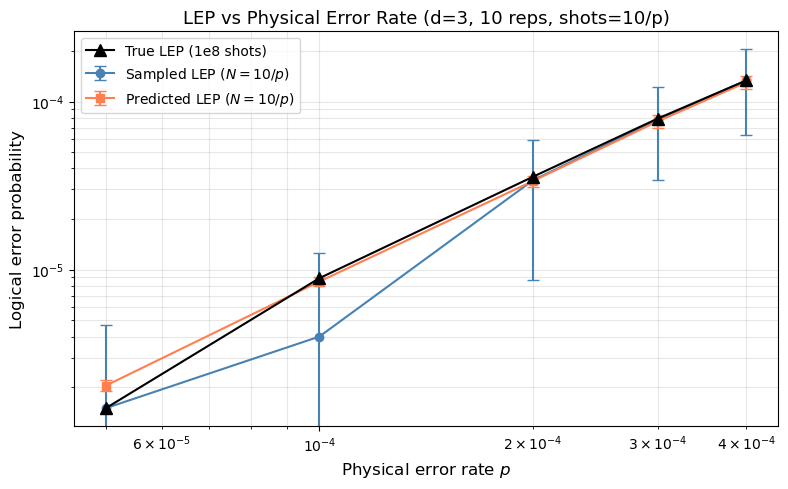

In [ ]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))

# True LEP
ax.plot(p_values, true_leps, 'k^-', ms=8, lw=1.5, label='True LEP (1e8 shots)', zorder=3)

# Sampled LEP with error bars
s_means = [np.mean(sampled_leps[p]) for p in p_values]
s_stds = [np.std(sampled_leps[p]) for p in p_values]
ax.errorbar(p_values, s_means, yerr=s_stds, fmt='o-', color='steelblue',
            capsize=4, ms=6, lw=1.5, label=r'Sampled LEP ($N=10/p$)')

# Predicted LEP with error bars
p_means = [np.mean(predicted_leps[p]) for p in p_values]
p_stds = [np.std(predicted_leps[p]) for p in p_values]
ax.errorbar(p_values, p_means, yerr=p_stds, fmt='s-', color='coral',
            capsize=4, ms=6, lw=1.5, label=r'Predicted LEP ($N=10/p$)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Physical error rate $p$', fontsize=12)
ax.set_ylabel('Logical error probability', fontsize=12)
ax.set_title(f'LEP vs Physical Error Rate (d={d}, {n_reps} reps, shots={n_reps}/p)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Step 4: Sample Complexity — Minimum Shots for 10% Relative Precision

We subsample from the experiment’s `shots` pool at increasing sample sizes and measure
the relative error of both the sampled LEP and predicted LEP against `bench.true_lep`.

In [ ]:
import time
from sim_qec.detector_error_models.circuit_lep_prediction import PredictPriors
from sim_qec.detector_error_models.circuit_decoders import BPLSD_Decoder

h = result.check_matrix
l = result.observables_matrix
true_priors = result.true_priors
dem_vals_full = result.dem_vals
log_vals_full = result.log_vals
true_lep = bench.true_lep

BPLSD_PARAMS = {
    'max_iter': 5, 'bp_method': 'min_sum', 'ms_scaling_factor': 0.5,
    'schedule': 'parallel', 'lsd_method': 'lsd_e', 'lsd_order': 3,
}

sample_sizes = [1_000, 5_000, 10_000, 50_000, 100_000,
                500_000, 1_000_000, 5_000_000]

results_sampled = []   # (N, lep_sampled, relative_error)
results_predicted = [] # (N, lep_predicted, relative_error)

rng = np.random.default_rng(42)

for N in sample_sizes:
    idx = rng.choice(len(dem_vals_full), size=N, replace=False)
    dem_sub = dem_vals_full[idx]
    log_sub = log_vals_full[idx]

    # --- Sampled LEP at this N ---
    decoder = BPLSD_Decoder(BPLSD_params=BPLSD_PARAMS)
    decoder.set_decoder({'H': h, 'L': l, 'channel_probs': true_priors})
    corrections = decoder.decode(dem_sub)
    les = ((log_sub + (corrections @ l.T) % 2) % 2).any(axis=1).astype(int)
    lep_s = float(np.average(les))
    rel_err_s = abs(lep_s - true_lep) / true_lep if true_lep > 0 else np.inf
    results_sampled.append((N, lep_s, rel_err_s))

    # --- Predicted LEP at this N ---
    predictor = PredictPriors(dectector_samples=dem_sub, check_matrix=h, subsample=True)
    A_syn, stabs = predictor._build_A_matrix_syndromes()
    stab_eigs = predictor._get_syndrome_expectations(sample_stabs=stabs)
    pred_priors = predictor.predict_priors(A_syn, stab_eigs, mode='rip')

    lep_p = predictor.predict_logical_error_efficient(
        decoder=decoder, observables_matrix=l,
        priors=pred_priors, max_order=4,
    )
    rel_err_p = abs(lep_p - true_lep) / true_lep if true_lep > 0 else np.inf
    results_predicted.append((N, lep_p, rel_err_p))

    print(f'N={N:>11,}  |  sampled LEP={lep_s:.4e} (err={rel_err_s:.1%})  '
          f'|  predicted LEP={lep_p:.4e} (err={rel_err_p:.1%})')

the detector shape is: (1000, 8)
N=      1,000  |  sampled LEP=0.0000e+00 (err=100.0%)  |  predicted LEP=4.3875e-04 (err=119.4%)
the detector shape is: (5000, 8)
N=      5,000  |  sampled LEP=2.0000e-04 (err=1.0%)  |  predicted LEP=6.2980e-03 (err=3050.0%)
the detector shape is: (10000, 8)
N=     10,000  |  sampled LEP=1.0000e-04 (err=50.5%)  |  predicted LEP=1.9769e-04 (err=1.1%)
the detector shape is: (50000, 8)
N=     50,000  |  sampled LEP=2.8000e-04 (err=38.6%)  |  predicted LEP=2.0614e-04 (err=3.1%)
the detector shape is: (100000, 8)
N=    100,000  |  sampled LEP=2.5000e-04 (err=23.8%)  |  predicted LEP=1.9837e-04 (err=0.8%)
the detector shape is: (500000, 8)
N=    500,000  |  sampled LEP=1.9800e-04 (err=2.0%)  |  predicted LEP=2.1208e-04 (err=6.1%)
the detector shape is: (1000000, 8)
N=  1,000,000  |  sampled LEP=1.8900e-04 (err=6.4%)  |  predicted LEP=2.0006e-04 (err=0.1%)
the detector shape is: (5000000, 8)
N=  5,000,000  |  sampled LEP=1.9720e-04 (err=2.4%)  |  predicted LEP=

### Minimum samples for 10% relative precision

In [ ]:
threshold = 0.10  # 10% relative error

N_star_sampled = None
for N, _, rel_err in results_sampled:
    if rel_err <= threshold:
        N_star_sampled = N
        break

N_star_predicted = None
for N, _, rel_err in results_predicted:
    if rel_err <= threshold:
        N_star_predicted = N
        break

print(f"Minimum shots for ≤10% relative error (vs true LEP = {true_lep:.4e}):")
print(f"  Sampled LEP:   N* = {N_star_sampled:,}" if N_star_sampled else "  Sampled LEP:   not reached")
print(f"  Predicted LEP: N* = {N_star_predicted:,}" if N_star_predicted else "  Predicted LEP: not reached")

Minimum shots for ≤10% relative error:
  Sampled LEP:   N* = 5,000
  Predicted LEP: N* = 10,000


### Convergence plot

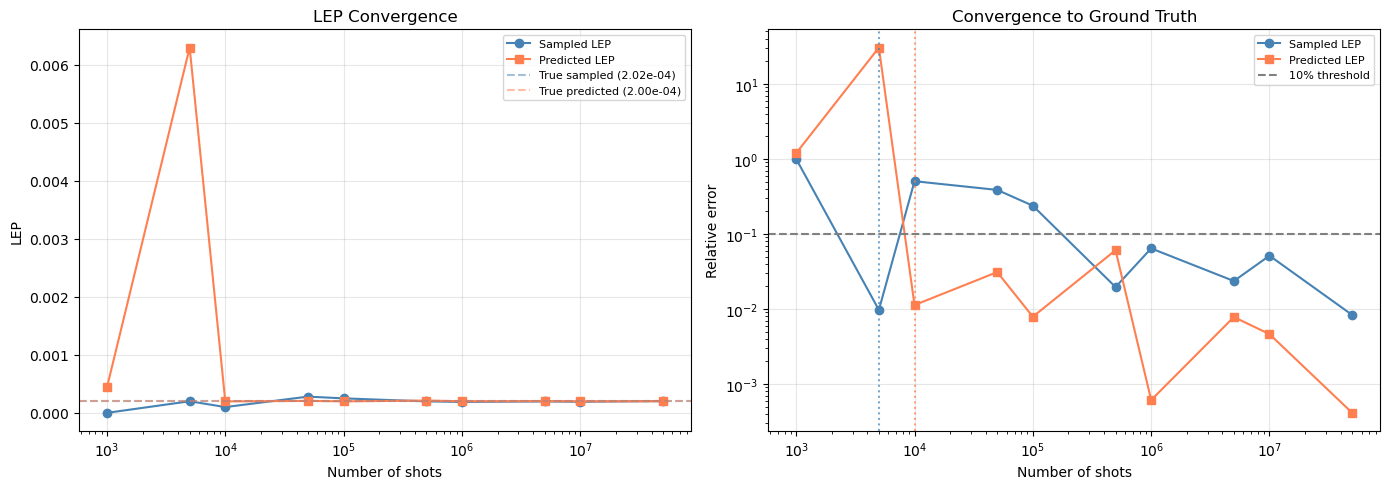

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Ns = [r[0] for r in results_sampled]

# --- Left: LEP vs sample size ---
ax = axes[0]
ax.plot(Ns, [r[1] for r in results_sampled], 'o-', label='Sampled LEP', color='steelblue')
ax.plot(Ns, [r[1] for r in results_predicted], 's-', label='Predicted LEP', color='coral')
ax.axhline(true_lep, ls='--', color='gray', alpha=0.7, label=f'True LEP ({true_lep:.2e})')
ax.set_xscale('log')
ax.set_xlabel('Number of shots')
ax.set_ylabel('LEP')
ax.set_title('LEP Convergence')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Right: Relative error vs sample size ---
ax = axes[1]
ax.plot(Ns, [r[2] for r in results_sampled], 'o-', label='Sampled LEP', color='steelblue')
ax.plot(Ns, [r[2] for r in results_predicted], 's-', label='Predicted LEP', color='coral')
ax.axhline(threshold, ls='--', color='gray', lw=1.5, label='10% threshold')

if N_star_sampled:
    ax.axvline(N_star_sampled, ls=':', color='steelblue', alpha=0.7)
if N_star_predicted:
    ax.axvline(N_star_predicted, ls=':', color='coral', alpha=0.7)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of shots')
ax.set_ylabel('Relative error')
ax.set_title('Convergence to True LEP')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()